In [1]:
from transformers import AutoConfig, AutoTokenizer
import pandas as pd

from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.preprocessing import FunctionTransformer
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import f1_score, roc_auc_score
from sklearn.utils import resample
from sklearn.base import clone

import optuna
import ast

import seaborn as sns
import matplotlib.pyplot as plt
from nltk.corpus import stopwords
import numpy as np
import wandb
from collections import Counter

In [2]:
cap_df_complete = pd.read_csv('../cap_data.csv')

In [3]:
parlbert = "chkla/parlbert-topic-german"

tokenizer = AutoTokenizer.from_pretrained(parlbert)
config = AutoConfig.from_pretrained(parlbert)

id2label = config.id2label
label2id = config.label2id
label_list = [label for idx, label in sorted(id2label.items())]

In [5]:
# Preprocessing

In [4]:
# context split, train 70%, dev 15%, test 15%
docs = cap_df_complete[["date"]].drop_duplicates()
train_docs, temp_docs = train_test_split(docs, test_size=0.3, random_state=42)
dev_docs, test_docs   = train_test_split(temp_docs, test_size=0.5, random_state=42)

cap_df_complete['svm_text'] = cap_df_complete['svm_text'].apply(ast.literal_eval)
cap_df_complete['svm_text_lemmas'] = cap_df_complete['svm_text_lemmas'].apply(ast.literal_eval)

train_df = cap_df_complete.merge(train_docs, on=["date"])
dev_df   = cap_df_complete.merge(dev_docs, on=["date"])
test_df  = cap_df_complete.merge(test_docs, on=["date"])

train_texts = train_df["svm_text"].tolist()
dev_texts   = dev_df["svm_text"].tolist()
test_texts  = test_df["svm_text"].tolist()

train_texts_lemmas = train_df["svm_text_lemmas"].tolist()
dev_texts_lemmas   = dev_df["svm_text_lemmas"].tolist()
test_texts_lemmas  = test_df["svm_text_lemmas"].tolist()

train_labels = train_df["mapped_label"].tolist()
dev_labels   = dev_df["mapped_label"].tolist()
test_labels  = test_df["mapped_label"].tolist()

In [5]:
print(f"Amount of train samples: {len(train_texts)}")
print(f"Amount of dev samples: {len(dev_texts)}")
print(f"Amount of test samples: {len(test_texts)}")

Amount of train samples: 17521
Amount of dev samples: 4397
Amount of test samples: 4077


In [8]:
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\hanna\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [9]:
# Balanced data versions

In [8]:
def balance_dataset(texts, labels, max_samples=2000, random_state=42):
    """
    Balances a dataset by downsampling each class to a maximum number of samples (default: 2k per class).

    Parameters:
        texts (list): List of text samples.
        labels (list): Corresponding list of labels.
        max_samples (int): Maximum number of samples per class.
        random_state (int): Random state for reproducibility.

    Returns:
        balanced_texts (list): List of balanced text samples.
        balanced_labels (list): List of balanced labels.
    """
    df = pd.DataFrame({
        "text": texts,
        "label": labels
    })

    balanced_dfs = []

    for cls, group in df.groupby("label"):
        if len(group) > max_samples:
            group_downsampled = resample(
                group,
                replace=False,
                n_samples=max_samples,
                random_state=random_state
            )
            balanced_dfs.append(group_downsampled)
        else:
            balanced_dfs.append(group)

    df_balanced = pd.concat(balanced_dfs).sample(frac=1, random_state=random_state)

    balanced_texts = df_balanced["text"].tolist()
    balanced_labels = df_balanced["label"].tolist()

    return balanced_texts, balanced_labels

In [9]:
# train
texts_balanced, labels_balanced = balance_dataset(
    train_texts,
    train_labels,
    max_samples=2000
)

# train (lemmatized)
texts_balanced_lemmas, labels_balanced_lemmas = balance_dataset(
    train_texts_lemmas,
    train_labels,
    max_samples=2000
)

# train + dev
texts_final_train  = train_texts + dev_texts
labels_final_train = train_labels + dev_labels

texts_balanced_final, labels_balanced_final = balance_dataset(
    texts_final_train,
    labels_final_train,
    max_samples=2000
)

# train + dev (lemmatized)
texts_final_train_lemmas  = train_texts_lemmas + dev_texts_lemmas
labels_final_train = train_labels + dev_labels

texts_balanced_final_lemmas, labels_balanced_final_lemmas = balance_dataset(
    texts_final_train_lemmas,
    labels_final_train,
    max_samples=2000
)

# Stopwords

In [10]:
german_stopwords = stopwords.words("german")

## Training

In [ ]:
# training (balanced dataset as hyperparameter)

In [13]:
def objective(trial):
    # --- Hyperparameters ---
    ngram_max_target = trial.suggest_int("ngram_max_target", 1, 3)
    ngram_max_context = trial.suggest_int("ngram_max_context", 1, 3)
    top_k = trial.suggest_categorical("top_k", [5000, 10000, 20000])
    use_tfidf = trial.suggest_categorical("use_tfidf", [True, False])
    use_lemmas = trial.suggest_categorical("use_lemmas", [True, False])
    remove_stopwords = trial.suggest_categorical("remove_stopwords", [True, False])
    num_context = trial.suggest_int("num_context", 0, 2)
    use_balanced = trial.suggest_categorical("use_balanced", [True, False])

    # --- SVM hyperparameters ---
    C = trial.suggest_float("C", 0.001, 10.0, log=True)
    max_iter = trial.suggest_int("max_iter", 1000, 10000)
    loss = trial.suggest_categorical("loss", ["hinge", "squared_hinge"])

    # --- Dataset selection ---
    if use_balanced:
        texts_full = texts_balanced_lemmas if use_lemmas else texts_balanced
        labels_full = labels_balanced
    else:
        texts_full = train_texts_lemmas if use_lemmas else train_texts
        labels_full = train_labels

    # --- Build shared context vocabulary ---
    all_context_train = []
    for seq in texts_full:
        if len(seq) > 1:
            all_context_train.append(seq[-2])  # prev1
        if len(seq) > 2:
            all_context_train.append(seq[0])   # prev2

    vec_context_template = (
        TfidfVectorizer(
            ngram_range=(1, ngram_max_context),
            stop_words=german_stopwords if remove_stopwords else None
        )
        if use_tfidf else
        CountVectorizer(
            ngram_range=(1, ngram_max_context),
            stop_words=german_stopwords if remove_stopwords else None
        )
    )
    vec_context_template.fit(all_context_train)

    # --- Clone for prev1 and prev2 ---
    vec_context1 = clone(vec_context_template)
    vec_context1.vocabulary_ = vec_context_template.vocabulary_
    vec_context2 = clone(vec_context_template)
    vec_context2.vocabulary_ = vec_context_template.vocabulary_

    # --- Function transformers ---
    extract_target = FunctionTransformer(lambda X: [x[-1] for x in X], validate=False)
    extract_prev1 = FunctionTransformer(lambda X: [x[-2] if len(x) > 1 else "" for x in X], validate=False)
    extract_prev2 = FunctionTransformer(lambda X: [x[0] if len(x) > 2 else "" for x in X], validate=False)

    # --- Target vectorizer ---
    vec_target = (
        TfidfVectorizer(
            ngram_range=(1, ngram_max_target),
            stop_words=german_stopwords if remove_stopwords else None
        )
        if use_tfidf else
        CountVectorizer(
            ngram_range=(1, ngram_max_target),
            stop_words=german_stopwords if remove_stopwords else None
        )
    )

    # --- Feature union ---
    feature_list = [("target", Pipeline([("extract", extract_target), ("vec", vec_target)]))]
    if num_context >= 1:
        feature_list.append(("prev1", Pipeline([("extract", extract_prev1), ("vec", vec_context1)])))
    if num_context == 2:
        feature_list.append(("prev2", Pipeline([("extract", extract_prev2), ("vec", vec_context2)])))
    features = FeatureUnion(feature_list)

    # --- Transform ---
    X_train = features.fit_transform(texts_full)
    X_val = features.transform(dev_texts_lemmas if use_lemmas else dev_texts)

    # --- Feature selection ---
    selector = SelectKBest(f_classif, k=min(top_k, X_train.shape[1]))
    X_train = selector.fit_transform(X_train, labels_full)
    X_val = selector.transform(X_val)

    # --- Train classifier ---
    clf = LinearSVC(C=C, class_weight="balanced", max_iter=max_iter, loss=loss)
    clf.fit(X_train, labels_full)

    # --- Evaluate ---
    preds = clf.predict(X_val)
    mean_f1 = f1_score(dev_labels, preds, average="macro")

    # --- Log to wandb ---
    wandb.log({
        "f1_macro": mean_f1,
        "num_context": num_context,
        "C": C,
        "max_iter": max_iter,
        "top_k": top_k,
        "use_balanced": use_balanced,
        "use_tfidf": use_tfidf,
        "use_lemmas": use_lemmas,
        "remove_stopwords": remove_stopwords
    })

    return mean_f1

In [20]:
wandb.init()
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=25)

C,▁▁█▁▁▂▁▁▁▂▁▁▁▁▁▁▁▁▁▁▁▁▁▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
f1_macro,▂▅▃▄▅▆▄▅█▄███▅▇▆█▇██▆▃█▂▁██▇▅▇▇▅▇▆█▇▃█▅▇
max_iter,▇▂▃▆▇▇█▃▄▅▅▃▆▄▃▂▃▁▁▁▆▁▄▂▄▂▁▂▂▂▆▁▇▁▁▂▁▂▂▅
num_context,▁▅▁▁▅▅▁███████▅▅████▅██▅████▅█▅█▁█████▅█
top_k,▁▃███▃▁▁▁▃▁▁▁▁▁▁▁▁▁▁▁▁█▁▁▁▁▁█▁█▁▃▁▁▁████
C,0.03116
f1_macro,0.47801
max_iter,5898
num_context,2
remove_stopwords,True
top_k,20000


[I 2026-02-23 16:06:38,320] A new study created in memory with name: no-name-6b680ae7-81be-471a-bd56-db19bef1ad86
[I 2026-02-23 16:06:48,762] Trial 0 finished with value: 0.45772461908553747 and parameters: {'ngram_max_target': 3, 'ngram_max_context': 3, 'top_k': 20000, 'use_tfidf': True, 'use_lemmas': True, 'remove_stopwords': False, 'num_context': 2, 'use_balanced': False, 'C': 0.0466796796554042, 'max_iter': 6664, 'loss': 'squared_hinge'}. Best is trial 0 with value: 0.45772461908553747.
[I 2026-02-23 16:06:50,980] Trial 1 finished with value: 0.3743076234397204 and parameters: {'ngram_max_target': 3, 'ngram_max_context': 1, 'top_k': 10000, 'use_tfidf': True, 'use_lemmas': False, 'remove_stopwords': False, 'num_context': 1, 'use_balanced': True, 'C': 0.0010173786059994015, 'max_iter': 3589, 'loss': 'hinge'}. Best is trial 0 with value: 0.45772461908553747.
[I 2026-02-23 16:06:53,509] Trial 2 finished with value: 0.42578555232404547 and parameters: {'ngram_max_target': 2, 'ngram_max_

In [ ]:
# results balanced

In [29]:
print("Best trial:")
best_trial = study.best_trial

print(f"  Value (F1 macro): {best_trial.value}")
print("  Params:")
for key, value in best_trial.params.items():
    print(f"    {key}: {value}")

Best trial:
  Value (F1 macro): 0.499493792040667
  Params:
    ngram_max_target: 1
    ngram_max_context: 1
    top_k: 20000
    use_tfidf: True
    use_lemmas: False
    remove_stopwords: True
    num_context: 2
    use_balanced: True
    C: 0.22350939065227313
    max_iter: 8212
    loss: squared_hinge


#### train final balanced model

In [22]:
num_context = 2

# -----------------------------
# 1. Combine train + dev
# -----------------------------
texts_full = texts_balanced_final
labels_full = labels_balanced_final

vec_target = TfidfVectorizer(ngram_range=(1, 1), stop_words=german_stopwords)

all_context_train = []
for seq in texts_full:
    if len(seq) > 1:
        all_context_train.append(seq[-2])  # prev1
    if len(seq) > 2:
        all_context_train.append(seq[0])   # prev2

vec_context_template = TfidfVectorizer(
    ngram_range=(1, 1),
    stop_words=german_stopwords
)
vec_context_template.fit(all_context_train)

vec_context1 = clone(vec_context_template)
vec_context1.vocabulary_ = vec_context_template.vocabulary_
vec_context2 = clone(vec_context_template)
vec_context2.vocabulary_ = vec_context_template.vocabulary_

extract_target = FunctionTransformer(lambda X: [x[-1] for x in X], validate=False)
extract_prev1 = FunctionTransformer(lambda X: [x[-2] if len(x) > 1 else "" for x in X], validate=False)
extract_prev2 = FunctionTransformer(lambda X: [x[0] if len(x) > 2 else "" for x in X], validate=False)

# --- FeatureUnion ---
feature_list = [("target", Pipeline([("extract", extract_target), ("vec", vec_target)]))]

if num_context >= 1:
    feature_list.append(("prev1", Pipeline([("extract", extract_prev1), ("vec", vec_context1)])))

if num_context == 2:
    feature_list.append(("prev2", Pipeline([("extract", extract_prev2), ("vec", vec_context2)])))

features = FeatureUnion(feature_list)

# --- Fit/train on full data ---
X_text = features.fit_transform(texts_full)
selector = SelectKBest(f_classif, k=min(20000, X_text.shape[1]))
X_full = selector.fit_transform(X_text, labels_full)

# --- Train classifier ---
svm_final = LinearSVC(
    C=0.22350939065227313,
    loss="squared_hinge",
    max_iter=8212,
    class_weight='balanced'
)
svm_final.fit(X_full, labels_full)

# --- Transform test set ---
X_test = features.transform(test_texts)
X_test = selector.transform(X_test)

# --- Predict ---
test_preds = svm_final.predict(X_test)

In [24]:
f1_macro = f1_score(test_labels, test_preds, average='macro')
f1_micro = f1_score(test_labels, test_preds, average='micro')
f1_weighted= f1_score(test_labels, test_preds, average='weighted')

print("F1-Macro on test set:", f1_macro)
print("F1-Micro on test set:", f1_micro)
print("F1 weighted:", f1_weighted)

print(classification_report(
    [id2label[i] for i in test_labels],
    [id2label[i] for i in test_preds]
))

F1-Macro on test set: 0.5134922094598755
F1-Micro on test set: 0.5962717684571989
F1 weighted: 0.603538177341936


C:\Users\hanna\miniconda3\envs\im2024\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\hanna\miniconda3\envs\im2024\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\hanna\miniconda3\envs\im2024\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


                precision    recall  f1-score   support

   Agriculture       0.27      1.00      0.43         3
         Civil       0.48      0.63      0.55       136
       Culture       1.00      0.45      0.62        11
       Defense       0.49      0.75      0.59       119
      Domestic       0.48      0.48      0.48       247
     Education       0.59      0.57      0.58        72
        Energy       0.66      0.67      0.66       210
   Environment       0.48      0.62      0.54       100
       Foreign       0.54      0.69      0.61       170
    Government       0.46      0.56      0.51       235
        Health       0.29      0.70      0.41        37
       Housing       0.44      0.46      0.45        24
   Immigration       0.26      0.61      0.36        51
 International       0.79      0.53      0.63      1158
         Labor       0.62      0.72      0.67       321
           Law       0.30      0.41      0.35        58
Macroeconomics       0.71      0.60      0.65  

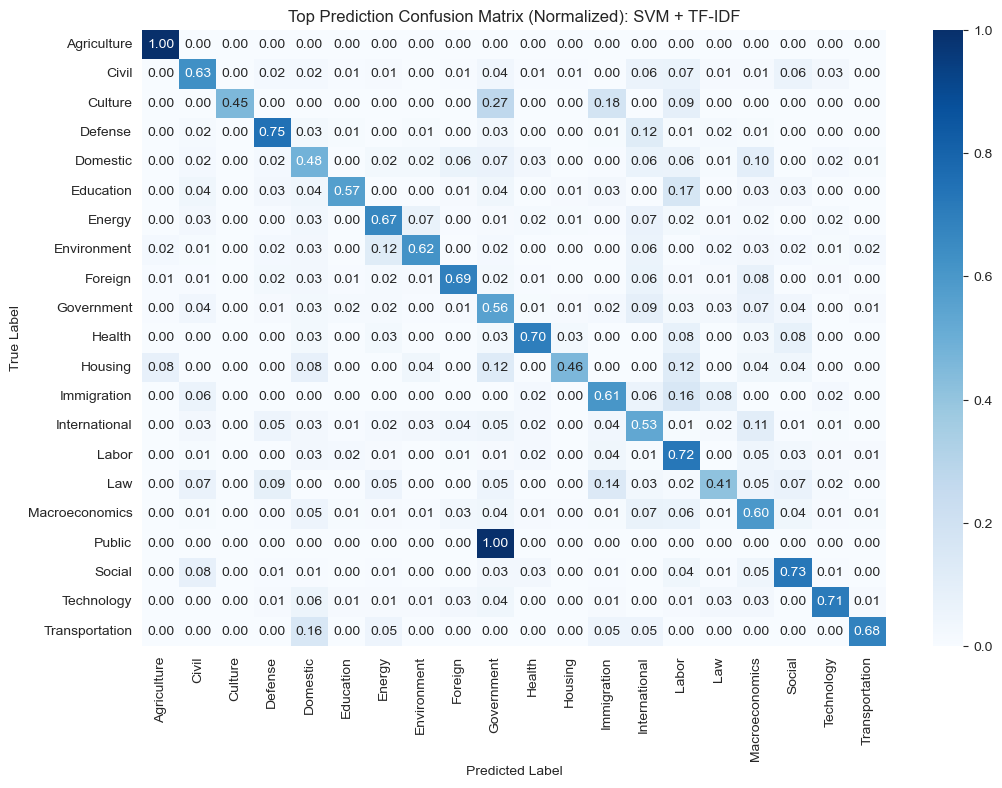

In [30]:
test_labels_named = [id2label[i] for i in test_labels]
pred_labels_named =  [id2label[i] for i in test_preds]

confusion_top = pd.crosstab(
    test_labels_named,
    pred_labels_named,
    rownames=['True Label'],
    colnames=['Predicted Label'],
    normalize='index'
)

plt.figure(figsize=(12,8))
sns.heatmap(confusion_top, annot=True, fmt=".2f", cmap="Blues")
plt.title("Top Prediction Confusion Matrix (Normalized): SVM + TF-IDF")
plt.savefig('svm_matrix.png',bbox_inches="tight")
plt.show()

In [ ]:
# Plot Label Distribution

In [26]:
labels_balanced_final_named =  [id2label[i] for i in labels_balanced_final]
labels_final_train_named = [id2label[i] for i in labels_final_train] 

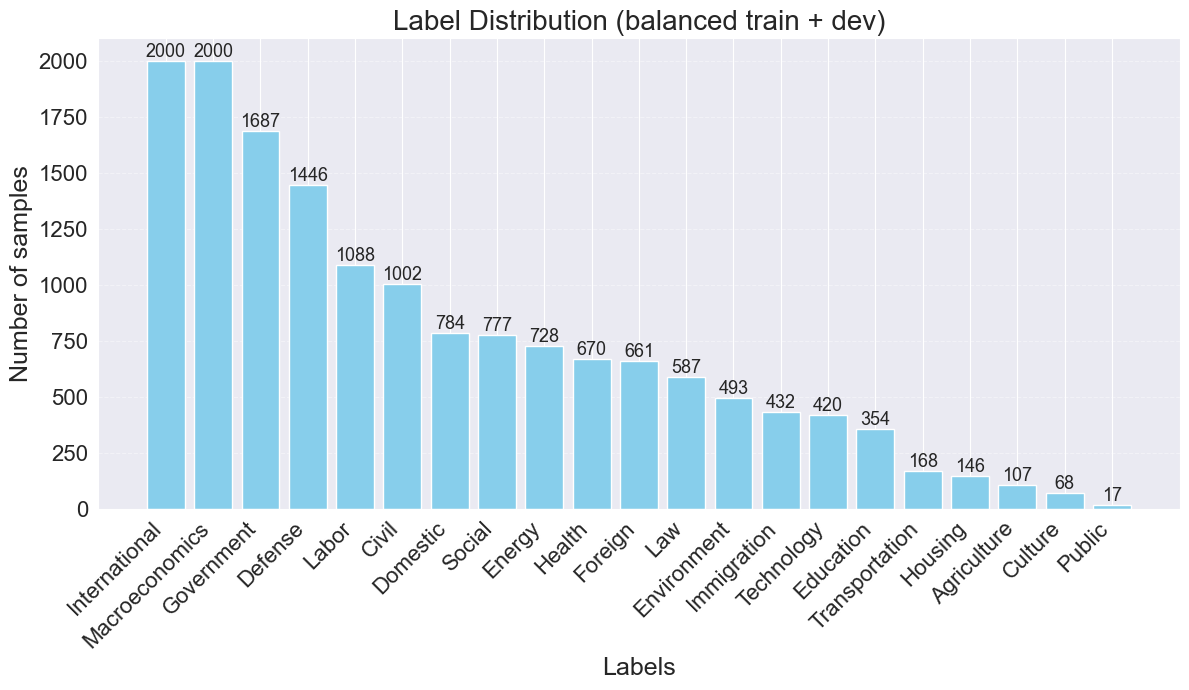

In [31]:
label_counts = Counter(labels_balanced_final_named)
labels, counts = zip(*sorted(label_counts.items(), key=lambda x: x[1], reverse=True))

x = np.arange(len(labels))

plt.figure(figsize=(12, 7))

bars = plt.bar(x, counts, color='skyblue')

plt.xticks(x, labels, rotation=45, ha='right', fontsize=16)
plt.yticks(fontsize=16)
plt.ylabel("Number of samples", fontsize=18)
plt.xlabel("Labels", fontsize=18)
plt.title("Label Distribution (balanced train + dev)", fontsize=20)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{int(height)}",
        ha='center',
        va='bottom',
        fontsize=13
    )

# --- Grid & layout ---
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()

# --- Save & show ---
plt.savefig('balanced_labeldis.png', bbox_inches="tight")
plt.show()

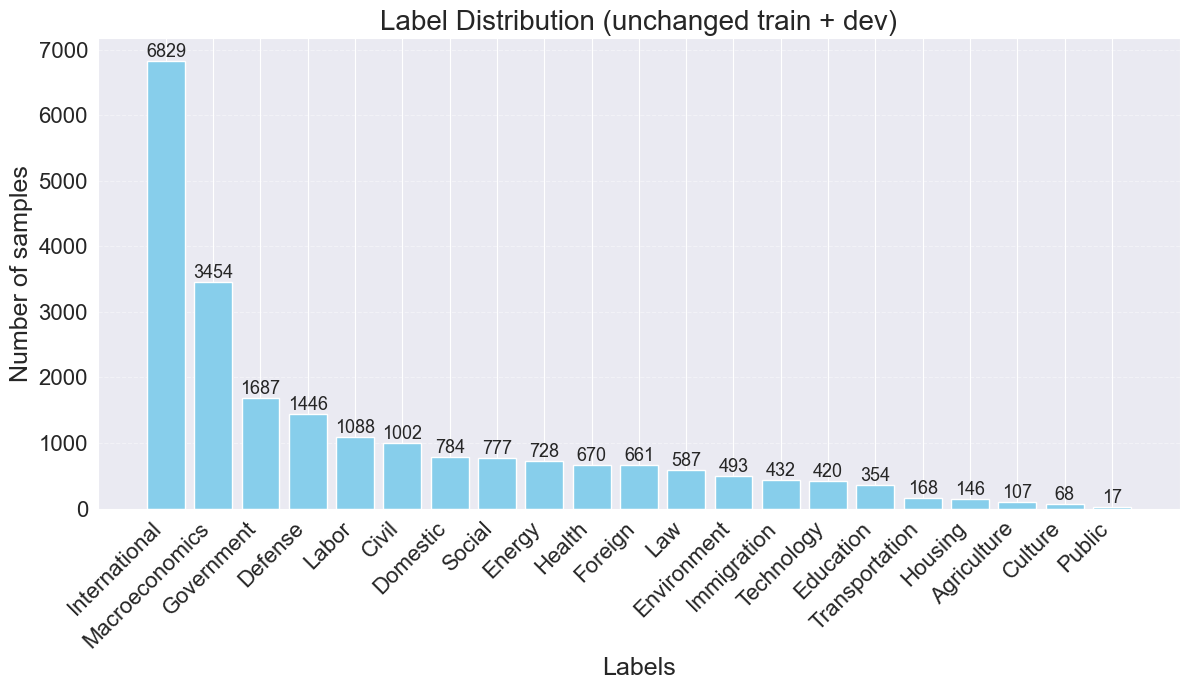

In [32]:
label_counts = Counter(labels_final_train_named)
labels, counts = zip(*sorted(label_counts.items(), key=lambda x: x[1], reverse=True))

x = np.arange(len(labels))

plt.figure(figsize=(12, 7))

bars = plt.bar(x, counts, color='skyblue')

plt.xticks(x, labels, rotation=45, ha='right', fontsize=16)
plt.yticks(fontsize=16)
plt.ylabel("Number of samples", fontsize=18)
plt.xlabel("Labels", fontsize=18)
plt.title("Label Distribution (unchanged train + dev)", fontsize=20)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{int(height)}",
        ha='center',
        va='bottom',
        fontsize=13
    )

# --- Grid & layout ---
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()

# --- Save & show ---
plt.savefig('unbalanced_labeldis.png', bbox_inches="tight")
plt.show()